# BSpline Refiner: Regularization-Focused Study

This notebook focuses on understanding regularization effects for the B-Spline contour refiner, as regularization parameters apply similarly across template models.

**Fixed Settings:**
*   **Refiner**: `BSplineContourRefiner` only
*   **Learning Rate**: 0.05
*   **Stochastic Sampling**: 128 profiles per iteration
*   **Symmetry**: Symmetric only (sigma1=sigma2, amp1=amp2)
*   **Template Control Points**: 8 (for BSpline template parameter variation)

**Variable Parameters (Minimal Strategic Grid):**

1. **Template Models** (2 representative):
   - `global` - Simple learnable baseline (single parameter set)
   - `bspline` - Best performing learned model (1D curve along contour)

2. **Regularization** (5 strategic combinations) - **PRIMARY FOCUS**:
   - **Diagonal**: (0.01, 0.01), (0.1, 0.1), (1.0, 1.0) - Balanced regularization
   - **Extremes**: (0.01, 1.0), (1.0, 0.01) - Laplacian vs Edge dominance
   
   Tests the trade-off between:
   - Low regularization (0.01) → More flexible, follows data closely
   - Medium regularization (0.1) → Balanced smoothness and data fit
   - High regularization (1.0) → Strong smoothness, may over-regularize
   - Imbalanced → Understand relative importance of Laplacian vs Edge

3. **Geometry Resolution** (2 endpoints):
   - **Control Points**: [20, 100] - Tests resolution sensitivity

**Total Experiments**: 20 (2 templates × 5 regularization pairs × 2 resolutions)

**Design Rationale**:
- **Regularization is primary focus**: All 5 strategic pairs tested to understand smoothness vs data-fitting trade-offs
- **Minimal template variation**: Global (simple) vs BSpline (learned) shows if regularization effects generalize
- **Symmetric only**: Reduces variables while focusing on regularization
- **Resolution endpoints**: Shows if regularization effects depend on spline resolution

**Goal**: Identify optimal regularization configuration that prevents shrinkage while maintaining smoothness, applicable to future template model development.

In [6]:
%load_ext autoreload
%autoreload 2

import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from tqdm.notebook import tqdm

import diffmeshopt.opt2d.vis as vis2d
from diffmeshopt.opt2d.evaluation import compute_contour_metrics, compute_reference_free_metrics
from diffmeshopt.opt2d.optimize import BSplineContourRefiner, ContourRefiner
from diffmeshopt.opt2d.props import (
    BSplineContourRefinerProps,
    BSplineTemplateProps,
    GaussianSplatTemplateProps,
    GridTemplateProps,
    NeuralFieldTemplateProps,
    TemplateProps,
)
from diffmeshopt.opt2d.template import TemplateModelFactory
from diffmeshopt.opt2d.trainer import AtomicParquetLogger, OptimizationTrainer, TrainerConfig


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading data from ../data/2d_training_data.pkl...


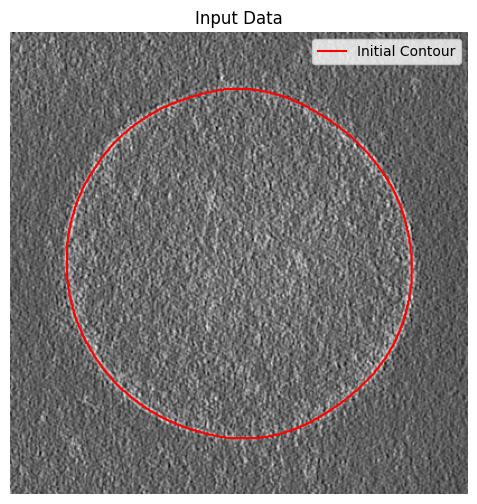

In [7]:
# 1. Load Data
data_path = Path("../data/2d_training_data.pkl")
if not data_path.exists():
    data_path = Path("/workspace/diffmeshopt/data/2d_training_data.pkl")

print(f"Loading data from {data_path}...")
data = joblib.load(data_path)
image_np = -data["image"]  # Invert intensity so membrane is dark
contour_np = data["contour"]

plt.figure(figsize=(6, 6))
plt.imshow(image_np, cmap="gray")
plt.plot(contour_np[:, 1], contour_np[:, 0], "r-", label="Initial Contour")
plt.legend()
plt.title("Input Data")
plt.axis("off")
plt.show()

In [10]:
# 2. Define Experiment Configurations
# Minimal grid focused on regularization effects
template_models = ["global", "bspline"]  # Simple vs learned
# Regularization: diagonal (equal) + extremes (imbalanced) - PRIMARY VARIABLE
regularization_pairs = [
    (0.01, 0.01),  # Low regularization (flexible, follows data)
    (0.1, 0.1),  # Moderate regularization (balanced)
    (1.0, 1.0),  # High regularization (smooth, may over-regularize)
    (0.01, 1.0),  # Low Laplacian, High Edge (prioritize edge consistency)
    (1.0, 0.01),  # High Laplacian, Low Edge (prioritize smoothness)
]
num_control_points_list = [20, 100]  # Coarse vs fine resolution

experiments = []
for template in template_models:
    # Only test symmetric (focus on regularization, not symmetry effects)
    for lap, edge in regularization_pairs:
        for ncp in num_control_points_list:
            experiments.append((template, True, lap, edge, ncp))

print(f"Defined {len(experiments)} experiments.")
print("\n=== Experimental Design (Regularization-Focused) ===")
print(f"Templates: {template_models}")
print("  - global: Simple baseline (single parameter set)")
print("  - bspline: Learned model (tests regularization generalization)")
print(f"\nRegularization pairs: {len(regularization_pairs)}")
print("  - Balanced: (0.01, 0.01) → (0.1, 0.1) → (1.0, 1.0)")
print("  - Imbalanced: (0.01, 1.0) vs (1.0, 0.01)")
print(f"\nResolution: {num_control_points_list} control points")
print(
    f"\nTotal: {len(template_models)} templates × {len(regularization_pairs)} reg pairs × "
    f"{len(num_control_points_list)} resolutions = {len(experiments)} experiments"
)


def get_config(template_mode, symmetric, laplacian_weight, edge_weight, num_control_points, steps):
    """Create configuration for BSpline refiner with given hyperparameters."""

    # BSpline Refiner Props
    refiner_props = BSplineContourRefinerProps(
        num_steps=steps,
        learning_rate=0.05,
        laplacian_loss_weight=laplacian_weight,
        edge_length_loss_weight=edge_weight,
        contour_num_control_points=num_control_points,
        num_sampled_profiles=128,
    )

    # Template Props (always symmetric in this study)
    template_props = TemplateProps(symmetric=True)
    if template_mode == "bspline":
        template_props = BSplineTemplateProps(
            **template_props.__dict__, bspline_num_control_points=8
        )

    return BSplineContourRefiner, refiner_props, template_props

Defined 20 experiments.

=== Experimental Design (Regularization-Focused) ===
Templates: ['global', 'bspline']
  - global: Simple baseline (single parameter set)
  - bspline: Learned model (tests regularization generalization)

Regularization pairs: 5
  - Balanced: (0.01, 0.01) → (0.1, 0.1) → (1.0, 1.0)
  - Imbalanced: (0.01, 1.0) vs (1.0, 0.01)

Resolution: [20, 100] control points

Total: 2 templates × 5 reg pairs × 2 resolutions = 20 experiments


In [11]:
# 3. Run Experiments
results = []
steps = 500
device = "cuda" if torch.cuda.is_available() else "cpu"

# Move data to device
image_torch = torch.from_numpy(image_np).float().to(device)
contour_torch = torch.from_numpy(contour_np).float().to(device)
img_shape = image_torch.shape

# Clean experiment directory
exp_dir = Path("../output/experiments/bspline_regularization_study/")
if exp_dir.exists():
    shutil.rmtree(exp_dir)

for template_mode, symmetric, lap_weight, edge_weight, ncp in tqdm(
    experiments, desc="All Experiments"
):
    label = f"{template_mode}_sym_L{lap_weight:.2f}_E{edge_weight:.2f}_cp{ncp}"
    print(f"Running: {label}")

    refiner_cls, refiner_props, template_props = get_config(
        template_mode, symmetric, lap_weight, edge_weight, ncp, steps
    )

    # Instantiate template model
    factory_kwargs = {
        "num_vertices": len(contour_torch),
        "image_shape": img_shape,
    }
    template_model = TemplateModelFactory.create(
        template_mode, props=template_props, **factory_kwargs
    ).to(device)

    # Instantiate refiner
    refiner = refiner_cls(
        initial_contour=contour_torch.clone(),
        props=refiner_props,
        template_model=template_model,
    )

    # Train
    run_dir = exp_dir / label
    config = TrainerConfig(
        output_dir=run_dir,
        image=image_np,
        gt_contour=None,
        save_images=True,
        use_tensorboard=True,
        log_interval=10,
        save_interval=200,
        max_steps=steps,
    )

    trainer = OptimizationTrainer(refiner, config, run_dir=run_dir)
    trainer.fit(steps_to_run=steps)

    # Get metrics from logger history
    logger = next((l for l in trainer.trainer.loggers if isinstance(l, AtomicParquetLogger)), None)
    history = logger.history if logger else []
    loss_history = [h["total_loss"] for h in history if "total_loss" in h]
    final_loss = loss_history[-1] if loss_history else np.nan

    # Evaluate final contour
    final_contour = refiner.contour.detach().cpu().numpy()
    with torch.no_grad():
        params_torch = refiner.template_model.get_params(coordinates=refiner.contour)
        params_np = {
            k: v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else v
            for k, v in params_torch.items()
        }

    # Compute reference-free metrics
    ref_free_metrics = compute_reference_free_metrics(final_contour)

    # Calculate area change (shrinkage indicator)
    initial_area = (
        np.abs(
            np.sum(
                (contour_np[:-1, 0] * contour_np[1:, 1]) - (contour_np[1:, 0] * contour_np[:-1, 1])
            )
        )
        / 2
    )
    final_area = (
        np.abs(
            np.sum(
                (final_contour[:-1, 0] * final_contour[1:, 1])
                - (final_contour[1:, 0] * final_contour[:-1, 1])
            )
        )
        / 2
    )
    area_change_pct = 100 * (final_area - initial_area) / initial_area

    # Store results
    res_entry = {
        "Template": template_mode,
        "Laplacian Weight": lap_weight,
        "Edge Weight": edge_weight,
        "Num Control Points": ncp,
        "Label": label,
        "Final Loss": final_loss,
        "Perimeter": ref_free_metrics.get("perimeter", np.nan),
        "Roughness": ref_free_metrics.get("roughness", np.nan),
        "Area Change (%)": area_change_pct,
        "Final Area": final_area,
        "Contour": final_contour,
        "Template Params": params_np,
        "Loss History": loss_history,
        "RefinerObj": refiner.cpu(),
    }
    results.append(res_entry)

All Experiments:   0%|          | 0/20 [00:00<?, ?it/s]

Running: global_sym_L0.01_E0.01_cp20


/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /workspace/diffmeshopt/.pixi/envs/default/lib/python ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/experiments/bspline_regularization_study/global_sym_L0.01_E0.01_cp20 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_

Epoch 0: 100%|###| 500/500 [00:12<00:00, 39.06it/s, v_num=.0_0, total_loss=4.79]

`Trainer.fit` stopped: `max_steps=500` reached.


...

`Trainer.fit` stopped: `max_steps=500` reached.


Running: bspline_sym_L1.00_E0.01_cp100                                          


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/experiments/bspline_regularization_study/bspline_sym_L1.00_E0.01_cp100 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 0: 100%|###| 500/500 [00:12<00:00, 41.24it/s, v_num=.0_0, total_loss=1.44]

`Trainer.fit` stopped: `max_steps=500` reached.


=== Summary Statistics ===
Total experiments: 20

Overall statistics:


Avg Final Loss,Avg Area Change,Avg Roughness,Avg Perimeter
f64,f64,f64,f64
63.701397,-8.752973,0.002605,926.26824



=== Best Configurations ===

Top 10 by Final Loss (data fit):


Template,Laplacian Weight,Edge Weight,Num Control Points,Final Loss,Area Change (%)
str,f64,f64,i64,f64,f64
"""global""",0.01,0.01,100,0.729926,-0.65791
"""global""",0.01,1.0,100,0.752082,-0.490229
"""bspline""",0.01,0.01,100,0.753104,-0.52785
"""bspline""",0.01,1.0,100,0.782883,-0.283999
"""global""",0.1,0.1,100,0.81171,-0.630668
"""bspline""",0.1,0.1,100,0.868179,-0.408253
"""global""",1.0,0.01,100,1.443384,-0.809729
"""bspline""",1.0,0.01,100,1.444106,-0.7544
"""global""",1.0,1.0,100,1.446076,-0.753857



Top 10 by Area Preservation:


...

Laplacian Weight,Edge Weight,Avg Final Loss,Avg Area Change,Avg Roughness,Count
f64,f64,f64,f64,f64,u32
0.01,0.01,2.764241,-1.208694,0.003452,4
0.01,1.0,2.897508,-0.232663,0.004032,4
0.1,0.1,16.814295,-12.307047,0.001896,4
1.0,0.01,145.684428,-15.644406,0.001818,4
1.0,1.0,150.346514,-14.372054,0.001829,4



--- By Control Points ---


/tmp/ipykernel_8434/1230956806.py:126: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("Count"),


Num Control Points,Avg Final Loss,Avg Area Change,Avg Roughness,Count
i64,f64,f64,f64,u32
20,126.352673,-16.906811,0.001801,10
100,1.050122,-0.599135,0.00341,10



=== Visualization: Template Model Comparison ===


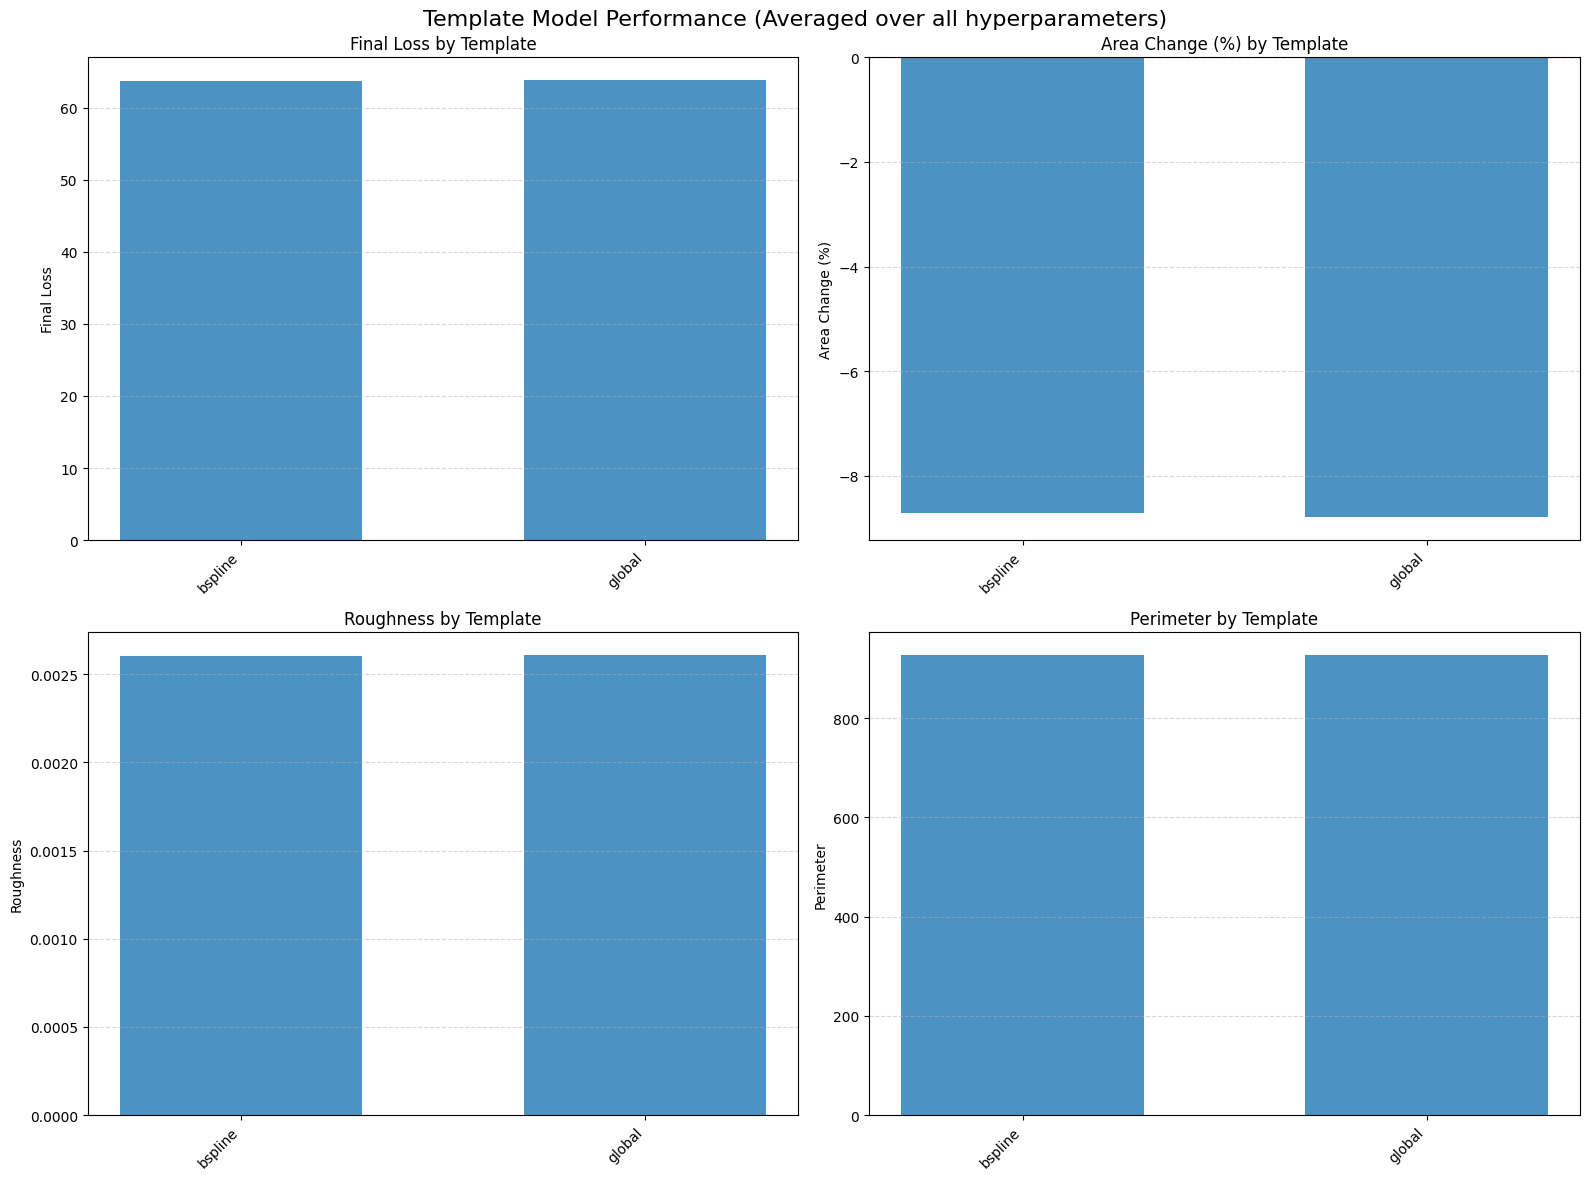


=== Regularization Effect (Heatmaps) ===


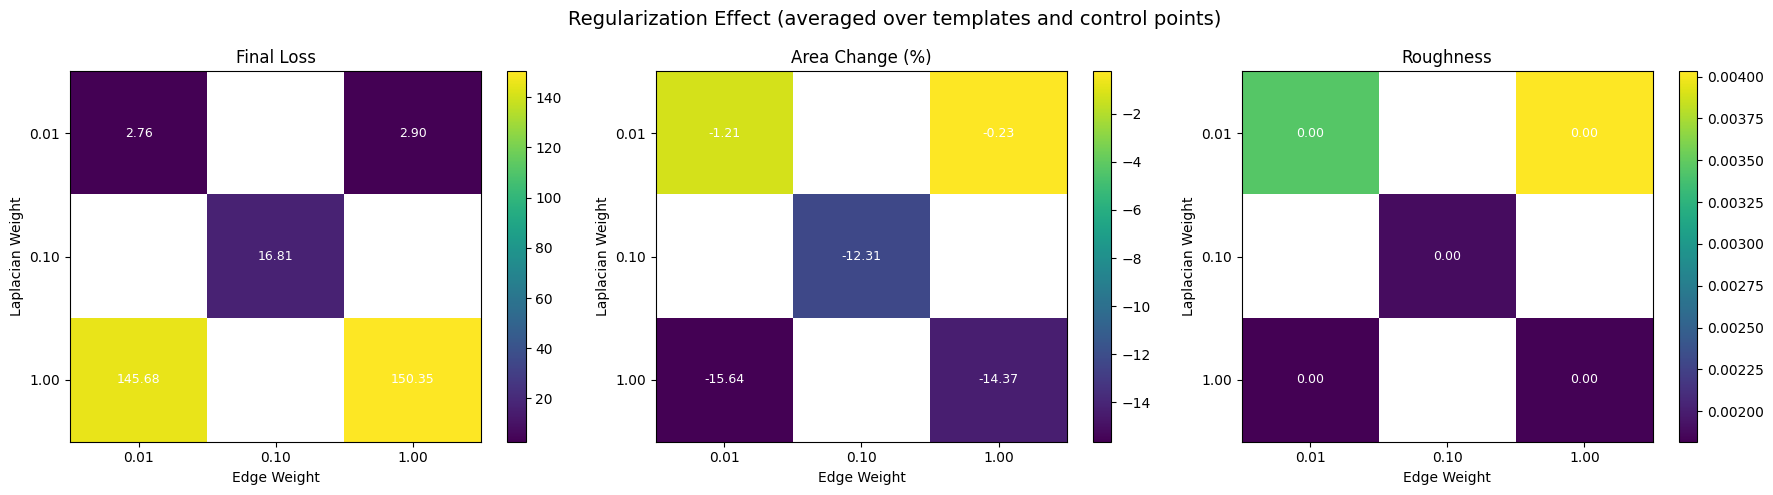

In [12]:
# 4. Quantitative Comparison (Tables & Visualizations)
if not results:
    print("No results to display.")
else:
    # Filter out complex objects
    simple_results = [
        {
            k: v
            for k, v in r.items()
            if k not in ["Contour", "Template Params", "Loss History", "RefinerObj"]
        }
        for r in results
    ]
    df = pl.DataFrame(simple_results)

    print("=== Summary Statistics ===")
    print(f"Total experiments: {len(df)}")
    print("\nOverall statistics:")
    display(
        df.select(
            [
                pl.col("Final Loss").mean().alias("Avg Final Loss"),
                pl.col("Area Change (%)").mean().alias("Avg Area Change"),
                pl.col("Roughness").mean().alias("Avg Roughness"),
                pl.col("Perimeter").mean().alias("Avg Perimeter"),
            ]
        )
    )

    # Find best configurations by different metrics
    print("\n=== Best Configurations ===")

    # Best by final loss
    best_loss = df.sort("Final Loss").head(10)
    print("\nTop 10 by Final Loss (data fit):")
    display(
        best_loss.select(
            [
                "Template",
                "Laplacian Weight",
                "Edge Weight",
                "Num Control Points",
                "Final Loss",
                "Area Change (%)",
            ]
        )
    )

    # Configurations with minimal shrinkage
    df_with_abs_area = df.with_columns(pl.col("Area Change (%)").abs().alias("Abs Area Change"))
    best_area_preservation = df_with_abs_area.sort("Abs Area Change").head(10)
    print("\nTop 10 by Area Preservation:")
    display(
        best_area_preservation.select(
            [
                "Template",
                "Laplacian Weight",
                "Edge Weight",
                "Num Control Points",
                "Area Change (%)",
                "Final Loss",
            ]
        )
    )

    # Best by smoothness
    best_smoothness = df.sort("Roughness").head(10)
    print("\nTop 10 by Smoothness (lowest roughness):")
    display(
        best_smoothness.select(
            [
                "Template",
                "Laplacian Weight",
                "Edge Weight",
                "Num Control Points",
                "Roughness",
                "Area Change (%)",
            ]
        )
    )

    # Analyze effect of each variable
    print("\n=== Factor Analysis ===")

    # Template effect
    print("\n--- By Template Model ---")
    template_stats = (
        df.group_by("Template")
        .agg(
            [
                pl.col("Final Loss").mean().alias("Avg Final Loss"),
                pl.col("Area Change (%)").mean().alias("Avg Area Change"),
                pl.col("Roughness").mean().alias("Avg Roughness"),
                pl.count().alias("Count"),
            ]
        )
        .sort("Avg Final Loss")
    )
    display(template_stats)

    # Regularization effect
    print("\n--- By Regularization ---")
    reg_stats = (
        df.group_by(["Laplacian Weight", "Edge Weight"])
        .agg(
            [
                pl.col("Final Loss").mean().alias("Avg Final Loss"),
                pl.col("Area Change (%)").mean().alias("Avg Area Change"),
                pl.col("Roughness").mean().alias("Avg Roughness"),
                pl.count().alias("Count"),
            ]
        )
        .sort("Avg Final Loss")
    )
    display(reg_stats)

    # Control points effect
    print("\n--- By Control Points ---")
    cp_stats = (
        df.group_by("Num Control Points")
        .agg(
            [
                pl.col("Final Loss").mean().alias("Avg Final Loss"),
                pl.col("Area Change (%)").mean().alias("Avg Area Change"),
                pl.col("Roughness").mean().alias("Avg Roughness"),
                pl.count().alias("Count"),
            ]
        )
        .sort("Num Control Points")
    )
    display(cp_stats)

    # Visualizations
    print("\n=== Visualization: Template Model Comparison ===")

    templates = sorted(df["Template"].unique().to_list())

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    metrics = ["Final Loss", "Area Change (%)", "Roughness", "Perimeter"]

    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        # Group by template
        template_data = (
            df.group_by("Template")
            .agg(pl.col(metric).mean().alias(f"Avg {metric}"))
            .sort("Template")
        )

        x = np.arange(len(templates))
        width = 0.6

        vals = []
        for t in templates:
            row = template_data.filter(pl.col("Template") == t)
            if not row.is_empty():
                vals.append(row[f"Avg {metric}"][0])
            else:
                vals.append(np.nan)

        ax.bar(x, vals, width, alpha=0.8)
        ax.set_ylabel(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(templates, rotation=45, ha="right")
        ax.set_title(f"{metric} by Template")
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if metric == "Area Change (%)":
            ax.axhline(y=0, color="r", linestyle="--", alpha=0.5, linewidth=1)

    plt.suptitle("Template Model Performance (Averaged over all hyperparameters)", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Regularization heatmaps
    print("\n=== Regularization Effect (Heatmaps) ===")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    heatmap_metrics = ["Final Loss", "Area Change (%)", "Roughness"]

    lap_vals = [pair[0] for pair in regularization_pairs]
    edge_vals = [pair[1] for pair in regularization_pairs]
    unique_lap = sorted(set(lap_vals))
    unique_edge = sorted(set(edge_vals))

    for idx, metric in enumerate(heatmap_metrics):
        ax = axes[idx]

        # Average over templates and control points
        pivot_data = df.group_by(["Laplacian Weight", "Edge Weight"]).agg(
            pl.col(metric).mean().alias(f"Avg {metric}")
        )

        heatmap_data = np.zeros((len(unique_lap), len(unique_edge)))
        for i, lap in enumerate(unique_lap):
            for j, edge in enumerate(unique_edge):
                val = pivot_data.filter(
                    (pl.col("Laplacian Weight") == lap) & (pl.col("Edge Weight") == edge)
                )[f"Avg {metric}"]
                if len(val) > 0:
                    heatmap_data[i, j] = val[0]
                else:
                    heatmap_data[i, j] = np.nan

        im = ax.imshow(heatmap_data, cmap="viridis", aspect="auto")
        ax.set_xticks(np.arange(len(unique_edge)))
        ax.set_yticks(np.arange(len(unique_lap)))
        ax.set_xticklabels([f"{e:.2f}" for e in unique_edge])
        ax.set_yticklabels([f"{l:.2f}" for l in unique_lap])
        ax.set_xlabel("Edge Weight")
        ax.set_ylabel("Laplacian Weight")
        ax.set_title(metric)

        plt.colorbar(im, ax=ax)

        # Annotate cells
        for i in range(len(unique_lap)):
            for j in range(len(unique_edge)):
                val = heatmap_data[i, j]
                if not np.isnan(val):
                    ax.text(
                        j, i, f"{val:.2f}", ha="center", va="center", color="white", fontsize=9
                    )

    plt.suptitle("Regularization Effect (averaged over templates and control points)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [13]:
import random
import torch
from diffmeshopt.opt2d.geometry import compute_normals

Visualizing top 10 combinations (by Final Loss):
  - global_sym_L0.01_E0.01_cp100: Final Loss = 0.730, AreaChange = -0.7%
  - global_sym_L0.01_E1.00_cp100: Final Loss = 0.752, AreaChange = -0.5%
  - bspline_sym_L0.01_E0.01_cp100: Final Loss = 0.753, AreaChange = -0.5%
  - bspline_sym_L0.01_E1.00_cp100: Final Loss = 0.783, AreaChange = -0.3%
  - global_sym_L0.10_E0.10_cp100: Final Loss = 0.812, AreaChange = -0.6%
  - bspline_sym_L0.10_E0.10_cp100: Final Loss = 0.868, AreaChange = -0.4%
  - global_sym_L1.00_E0.01_cp100: Final Loss = 1.443, AreaChange = -0.8%
  - bspline_sym_L1.00_E0.01_cp100: Final Loss = 1.444, AreaChange = -0.8%
  - global_sym_L1.00_E1.00_cp100: Final Loss = 1.446, AreaChange = -0.8%
  - bspline_sym_L1.00_E1.00_cp100: Final Loss = 1.470, AreaChange = -0.7%


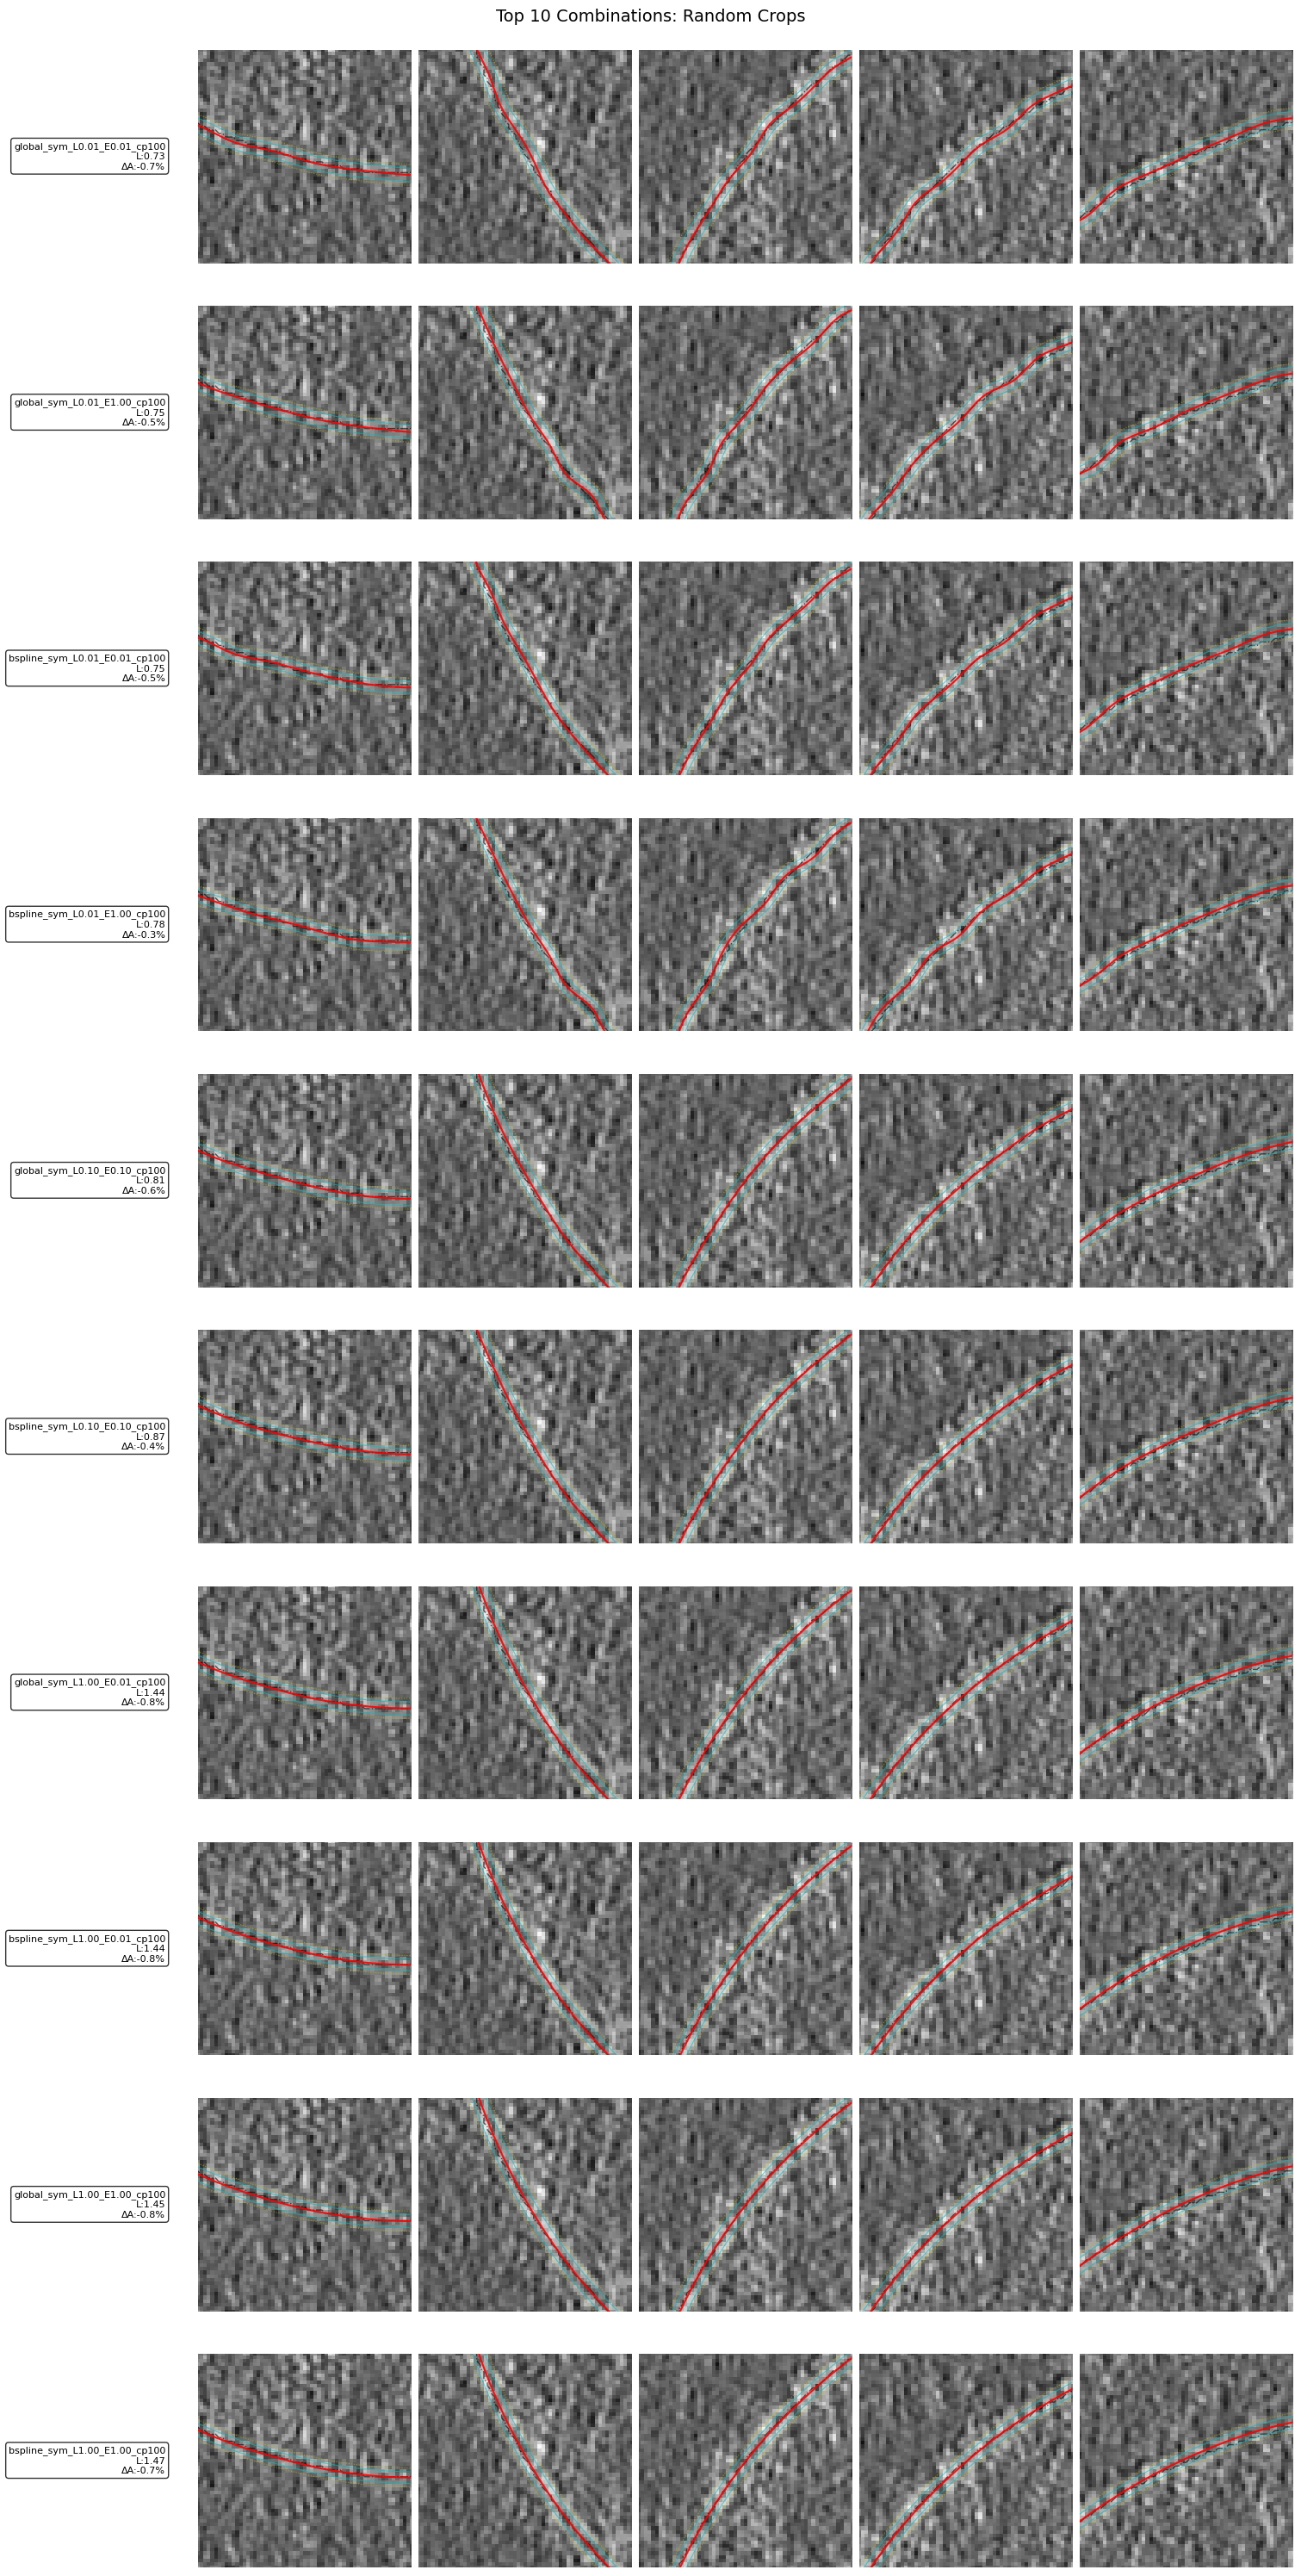

In [16]:
# 5. Qualitative Comparison: Top 10 - Random Crops
if not results:
    print("No results to visualize.")
else:
    # Select top 10 by Final Loss
    sorted_results = sorted(results, key=lambda x: x.get("Final Loss", float("inf")))
    top_10_results = sorted_results[:10]

    print(f"Visualizing top 10 combinations (by Final Loss):")
    for res in top_10_results:
        print(
            f"  - {res['Label']}: Final Loss = {res['Final Loss']:.3f}, "
            f"AreaChange = {res['Area Change (%)']:.1f}%"
        )

    # Setup cropping
    random.seed(42)
    num_crops = 5
    crop_size = 60
    H, W = image_np.shape[:2]
    half_size = crop_size // 2

    # Select crop indices
    if len(contour_np) > 0:
        indices = list(range(len(contour_np)))
        if len(indices) >= num_crops:
            crop_indices = sorted(random.sample(indices, num_crops))
        else:
            crop_indices = list(range(len(contour_np)))
    else:
        crop_indices = []

    fig, axes = plt.subplots(
        len(top_10_results),
        num_crops,
        figsize=(3 * num_crops, 3 * len(top_10_results)),
        constrained_layout=True,
    )

    if len(top_10_results) == 1:
        axes = axes[None, :]
    if num_crops == 1:
        axes = axes[:, None]

    for i, res in enumerate(top_10_results):
        template = res["Template"]
        final_contour = res["Contour"]
        params = res["Template Params"]

        # Compute normals
        normals_torch = compute_normals(torch.from_numpy(final_contour).float())
        normals = normals_torch.numpy()

        # Helper to broadcast param
        def get_p(key):
            val = params.get(key, 1.0)
            if np.isscalar(val) or val.ndim == 0:
                return np.full(len(final_contour), val)
            return val.flatten()

        peak_dist = get_p("peak_dist")
        sigma = get_p("sigma")  # Symmetric template

        # Calculate visualization lines
        peak1 = final_contour - normals * (peak_dist[:, None] / 2)
        peak2 = final_contour + normals * (peak_dist[:, None] / 2)
        p1_outer = peak1 - normals * sigma[:, None]
        p2_outer = peak2 + normals * sigma[:, None]

        for j, idx in enumerate(crop_indices):
            ax = axes[i, j]

            # Crop center from initial contour
            cy, cx = contour_np[idx]
            y_min = max(0, int(cy - half_size))
            y_max = min(H, int(cy + half_size))
            x_min = max(0, int(cx - half_size))
            x_max = min(W, int(cx + half_size))

            ax.imshow(image_np, cmap="gray")

            # Plot contours
            ax.plot(contour_np[:, 1], contour_np[:, 0], "k-.", alpha=0.6, lw=1, label="Init")
            ax.plot(
                final_contour[:, 1], final_contour[:, 0], "r-", alpha=0.9, lw=1.5, label="Final"
            )

            # Plot template visualization
            ax.plot(peak1[:, 1], peak1[:, 0], "c-", alpha=0.6, lw=0.8)
            ax.plot(peak2[:, 1], peak2[:, 0], "c-", alpha=0.6, lw=0.8)
            ax.plot(p1_outer[:, 1], p1_outer[:, 0], "y:", alpha=0.6, lw=0.8)
            ax.plot(p2_outer[:, 1], p2_outer[:, 0], "y:", alpha=0.6, lw=0.8)

            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_max, y_min)
            ax.axis("off")

            if j == 0:
                # Add label on the left
                label_text = (
                    f"{res['Label']}\nL:{res['Final Loss']:.2f}\nΔA:{res['Area Change (%)']:.1f}%"
                )
                ax.text(
                    -0.15,
                    0.5,
                    label_text,
                    transform=ax.transAxes,
                    va="center",
                    ha="right",
                    fontsize=8,
                    rotation=0,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                )

    plt.suptitle("Top 10 Combinations: Random Crops", fontsize=14)
    plt.show()

Visualizing top 10 combinations (by Final Loss) - Largest Deviation Crops:
  - global_sym_L0.01_E0.01_cp100: Final Loss = 0.730, AreaChange = -0.7%
  - global_sym_L0.01_E1.00_cp100: Final Loss = 0.752, AreaChange = -0.5%
  - bspline_sym_L0.01_E0.01_cp100: Final Loss = 0.753, AreaChange = -0.5%
  - bspline_sym_L0.01_E1.00_cp100: Final Loss = 0.783, AreaChange = -0.3%
  - global_sym_L0.10_E0.10_cp100: Final Loss = 0.812, AreaChange = -0.6%
  - bspline_sym_L0.10_E0.10_cp100: Final Loss = 0.868, AreaChange = -0.4%
  - global_sym_L1.00_E0.01_cp100: Final Loss = 1.443, AreaChange = -0.8%
  - bspline_sym_L1.00_E0.01_cp100: Final Loss = 1.444, AreaChange = -0.8%
  - global_sym_L1.00_E1.00_cp100: Final Loss = 1.446, AreaChange = -0.8%
  - bspline_sym_L1.00_E1.00_cp100: Final Loss = 1.470, AreaChange = -0.7%


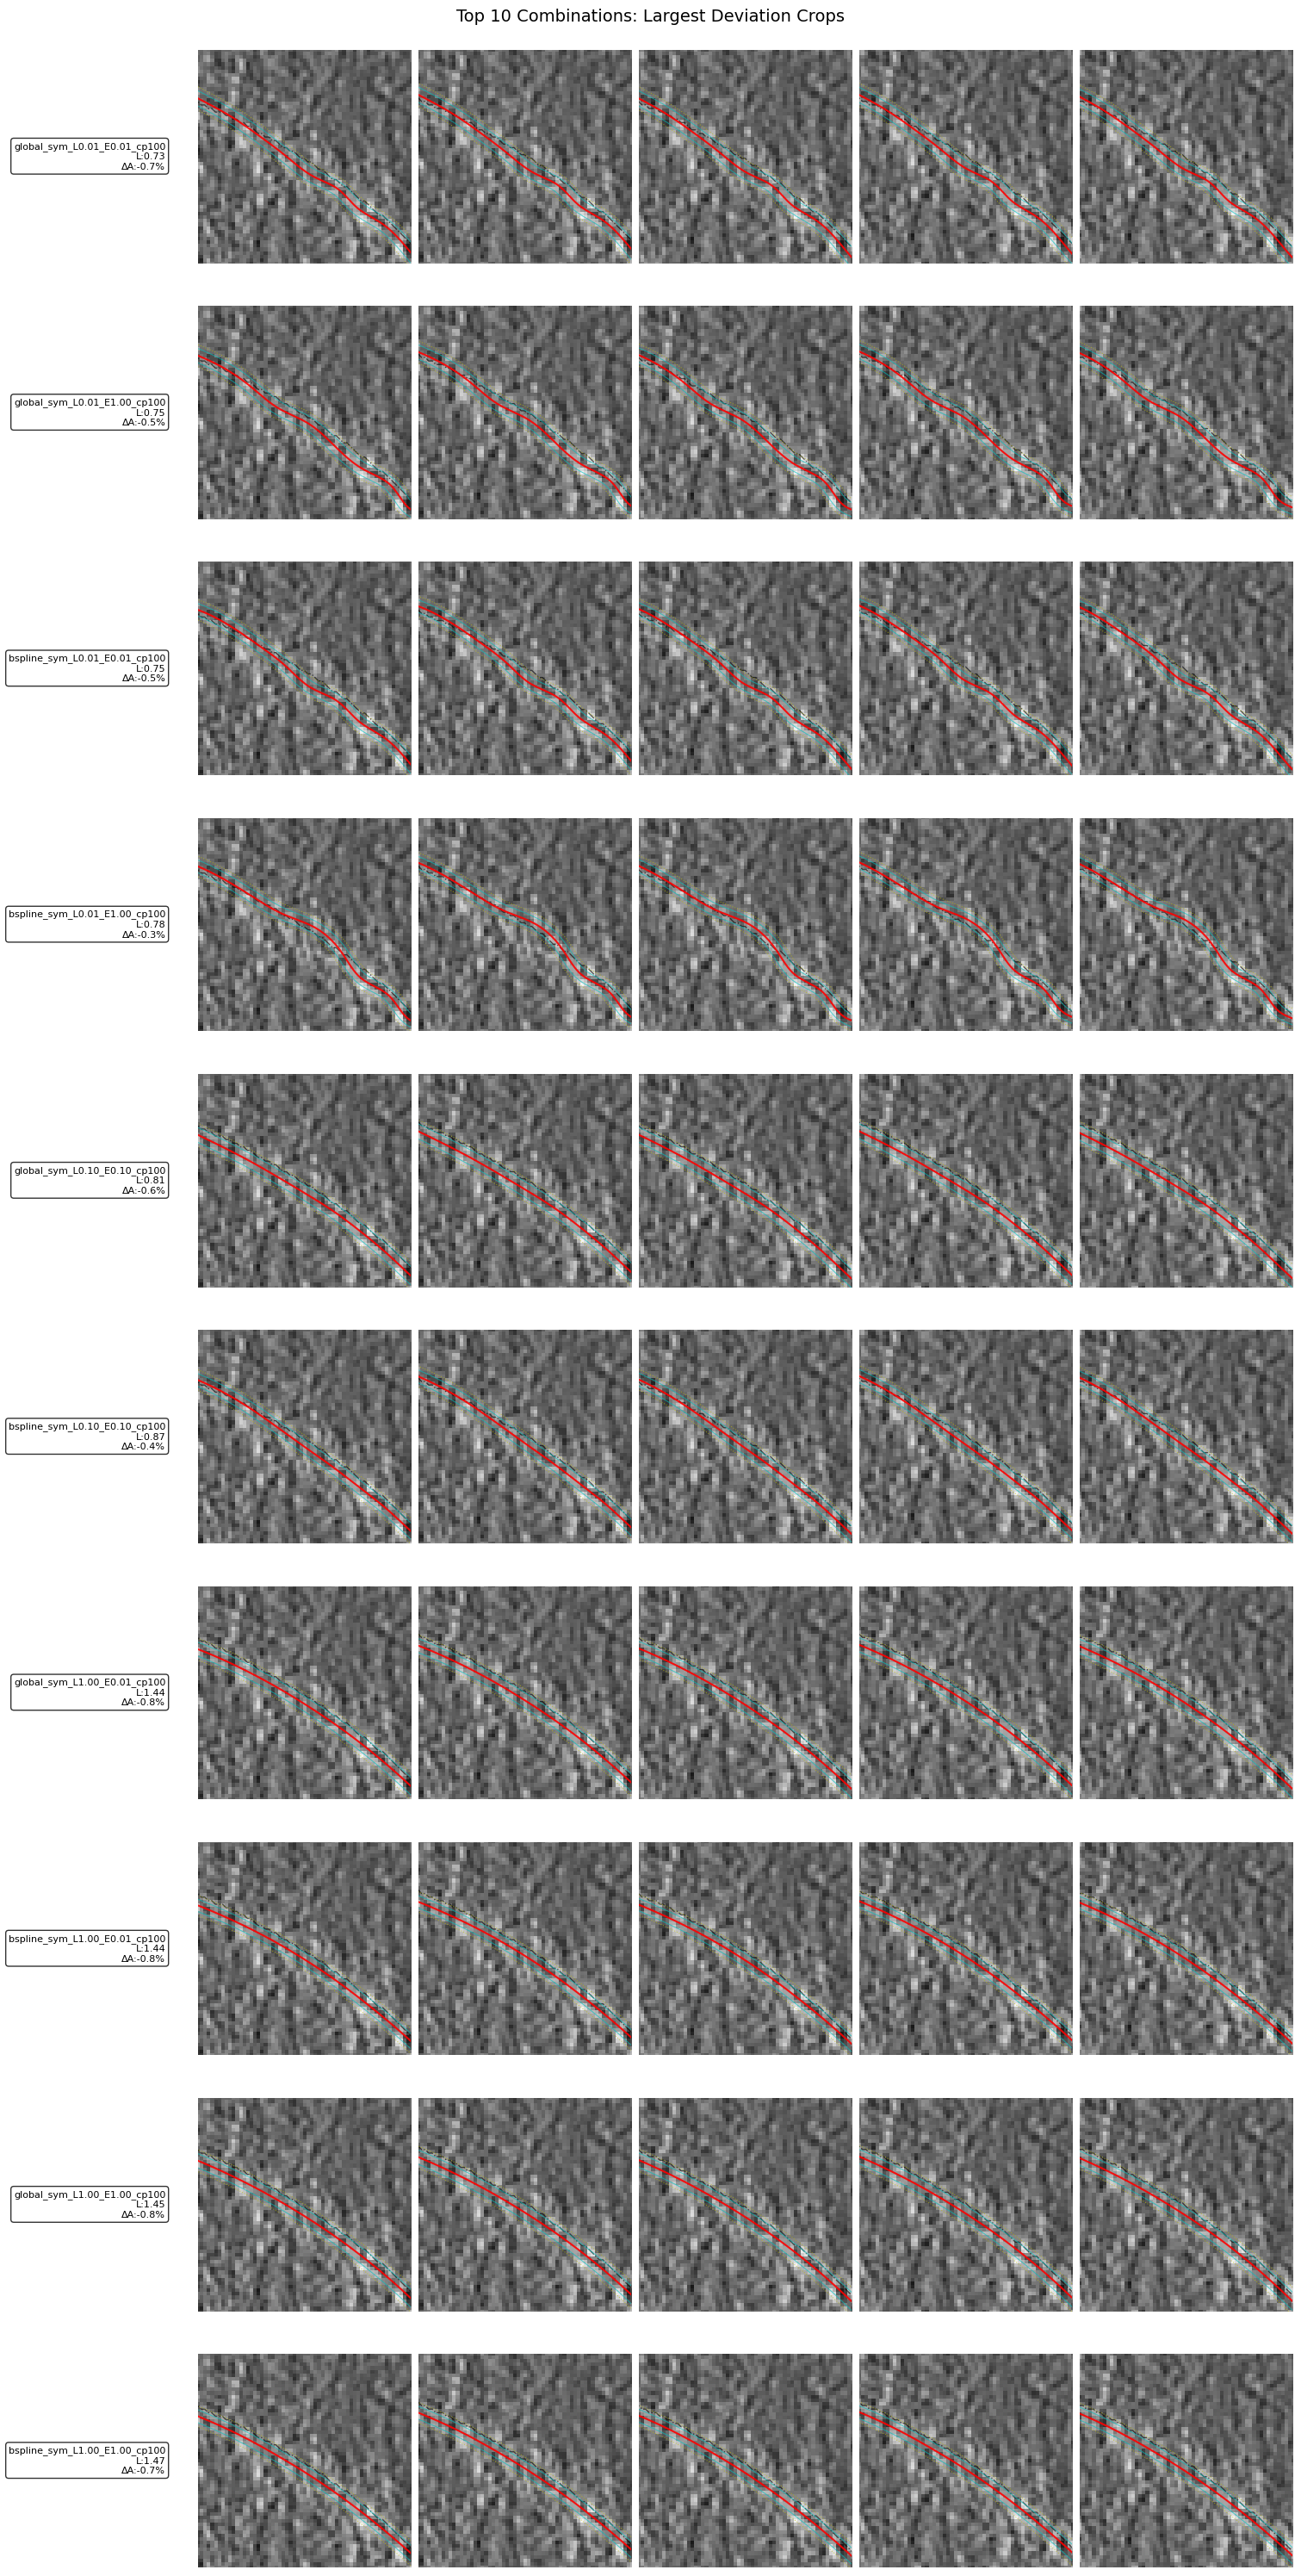

In [17]:
# 5b. Qualitative Comparison: Top 10 - Largest Deviation Crops
if not results:
    print("No results to visualize.")
else:
    # Select top 10 by Final Loss
    sorted_results = sorted(results, key=lambda x: x.get("Final Loss", float("inf")))
    top_10_results = sorted_results[:10]

    print(f"Visualizing top 10 combinations (by Final Loss) - Largest Deviation Crops:")
    for res in top_10_results:
        print(
            f"  - {res['Label']}: Final Loss = {res['Final Loss']:.3f}, "
            f"AreaChange = {res['Area Change (%)']:.1f}%"
        )

    # Setup cropping
    num_crops = 5
    crop_size = 60
    H, W = image_np.shape[:2]
    half_size = crop_size // 2

    # Find crop locations with largest deviations from initial contour
    crop_indices = []
    if len(contour_np) > 0:
        # Calculate distances between initial and a representative final contour
        representative_contour = top_10_results[0]["Contour"] if top_10_results else contour_np
        distances = np.linalg.norm(contour_np - representative_contour, axis=1)
        # Get indices of largest deviations
        sorted_indices = np.argsort(distances)[::-1]
        crop_indices = sorted(sorted_indices[:num_crops].tolist())

    fig, axes = plt.subplots(
        len(top_10_results),
        num_crops,
        figsize=(3 * num_crops, 3 * len(top_10_results)),
        constrained_layout=True,
    )

    if len(top_10_results) == 1:
        axes = axes[None, :]
    if num_crops == 1:
        axes = axes[:, None]

    for i, res in enumerate(top_10_results):
        template = res["Template"]
        final_contour = res["Contour"]
        params = res["Template Params"]

        # Compute normals
        normals_torch = compute_normals(torch.from_numpy(final_contour).float())
        normals = normals_torch.numpy()

        # Helper to broadcast param
        def get_p(key):
            val = params.get(key, 1.0)
            if np.isscalar(val) or val.ndim == 0:
                return np.full(len(final_contour), val)
            return val.flatten()

        peak_dist = get_p("peak_dist")
        sigma = get_p("sigma")  # Symmetric template

        # Calculate visualization lines
        peak1 = final_contour - normals * (peak_dist[:, None] / 2)
        peak2 = final_contour + normals * (peak_dist[:, None] / 2)
        p1_outer = peak1 - normals * sigma[:, None]
        p2_outer = peak2 + normals * sigma[:, None]

        for j, idx in enumerate(crop_indices):
            ax = axes[i, j]

            # Crop center from initial contour
            cy, cx = contour_np[idx]
            y_min = max(0, int(cy - half_size))
            y_max = min(H, int(cy + half_size))
            x_min = max(0, int(cx - half_size))
            x_max = min(W, int(cx + half_size))

            ax.imshow(image_np, cmap="gray")

            # Plot contours
            ax.plot(contour_np[:, 1], contour_np[:, 0], "k-.", alpha=0.6, lw=1, label="Init")
            ax.plot(
                final_contour[:, 1], final_contour[:, 0], "r-", alpha=0.9, lw=1.5, label="Final"
            )

            # Plot template visualization
            ax.plot(peak1[:, 1], peak1[:, 0], "c-", alpha=0.6, lw=0.8)
            ax.plot(peak2[:, 1], peak2[:, 0], "c-", alpha=0.6, lw=0.8)
            ax.plot(p1_outer[:, 1], p1_outer[:, 0], "y:", alpha=0.6, lw=0.8)
            ax.plot(p2_outer[:, 1], p2_outer[:, 0], "y:", alpha=0.6, lw=0.8)

            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_max, y_min)
            ax.axis("off")

            if j == 0:
                # Add label on the left
                label_text = (
                    f"{res['Label']}\nL:{res['Final Loss']:.2f}\nΔA:{res['Area Change (%)']:.1f}%"
                )
                ax.text(
                    -0.15,
                    0.5,
                    label_text,
                    transform=ax.transAxes,
                    va="center",
                    ha="right",
                    fontsize=8,
                    rotation=0,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                )

    plt.suptitle("Top 10 Combinations: Largest Deviation Crops", fontsize=14)
    plt.show()

=== Loss Convergence Analysis ===

Plotting loss curves for 5 representative configurations


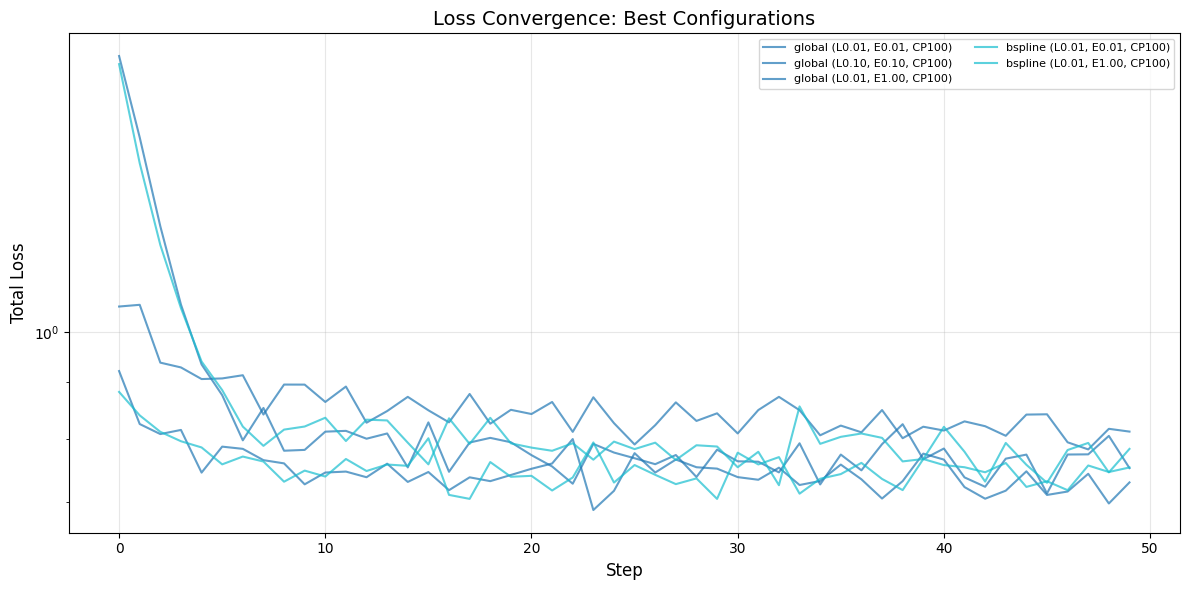

In [19]:
# 6. Loss Curves: Compare Convergence
if results:
    print("=== Loss Convergence Analysis ===")

    # Compare best configurations from different templates
    df_simple = pl.DataFrame(
        [
            {
                k: v
                for k, v in r.items()
                if k not in ["Contour", "Template Params", "Loss History", "RefinerObj"]
            }
            for r in results
        ]
    )

    # Get best configuration per template
    best_per_template = []
    for template in template_models:
        subset = df_simple.filter(pl.col("Template") == template)
        if not subset.is_empty():
            best = subset.sort("Final Loss").head(1)
            best_per_template.append(best["Label"][0])

    # Also get overall best configurations
    overall_best = df_simple.sort("Final Loss").head(5)["Label"].to_list()

    selected_labels = list(dict.fromkeys(best_per_template + overall_best))
    selected_results = [r for r in results if r["Label"] in selected_labels]

    print(f"\nPlotting loss curves for {len(selected_results)} representative configurations")

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    colors = plt.cm.tab10(np.linspace(0, 1, len(template_models)))
    template_to_color = {t: colors[i] for i, t in enumerate(template_models)}

    for res in selected_results:
        template = res["Template"]
        lap = res["Laplacian Weight"]
        edge = res["Edge Weight"]
        ncp = res["Num Control Points"]
        loss_hist = res["Loss History"]

        if len(loss_hist) > 0:
            label = f"{template} (L{lap:.2f}, E{edge:.2f}, CP{ncp})"
            ax.plot(
                loss_hist,
                label=label,
                alpha=0.7,
                linewidth=1.5,
                color=template_to_color[template],
            )

    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel("Total Loss", fontsize=12)
    ax.set_title("Loss Convergence: Best Configurations", fontsize=14)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2, loc="upper right")

    plt.tight_layout()
    plt.show()

=== Learned Template Parameters ===

Showing parameter variation for 2 template models:
  - global (Symmetric)
  - bspline (Symmetric)


/tmp/ipykernel_8434/1362604555.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9, loc="best", ncol=2)


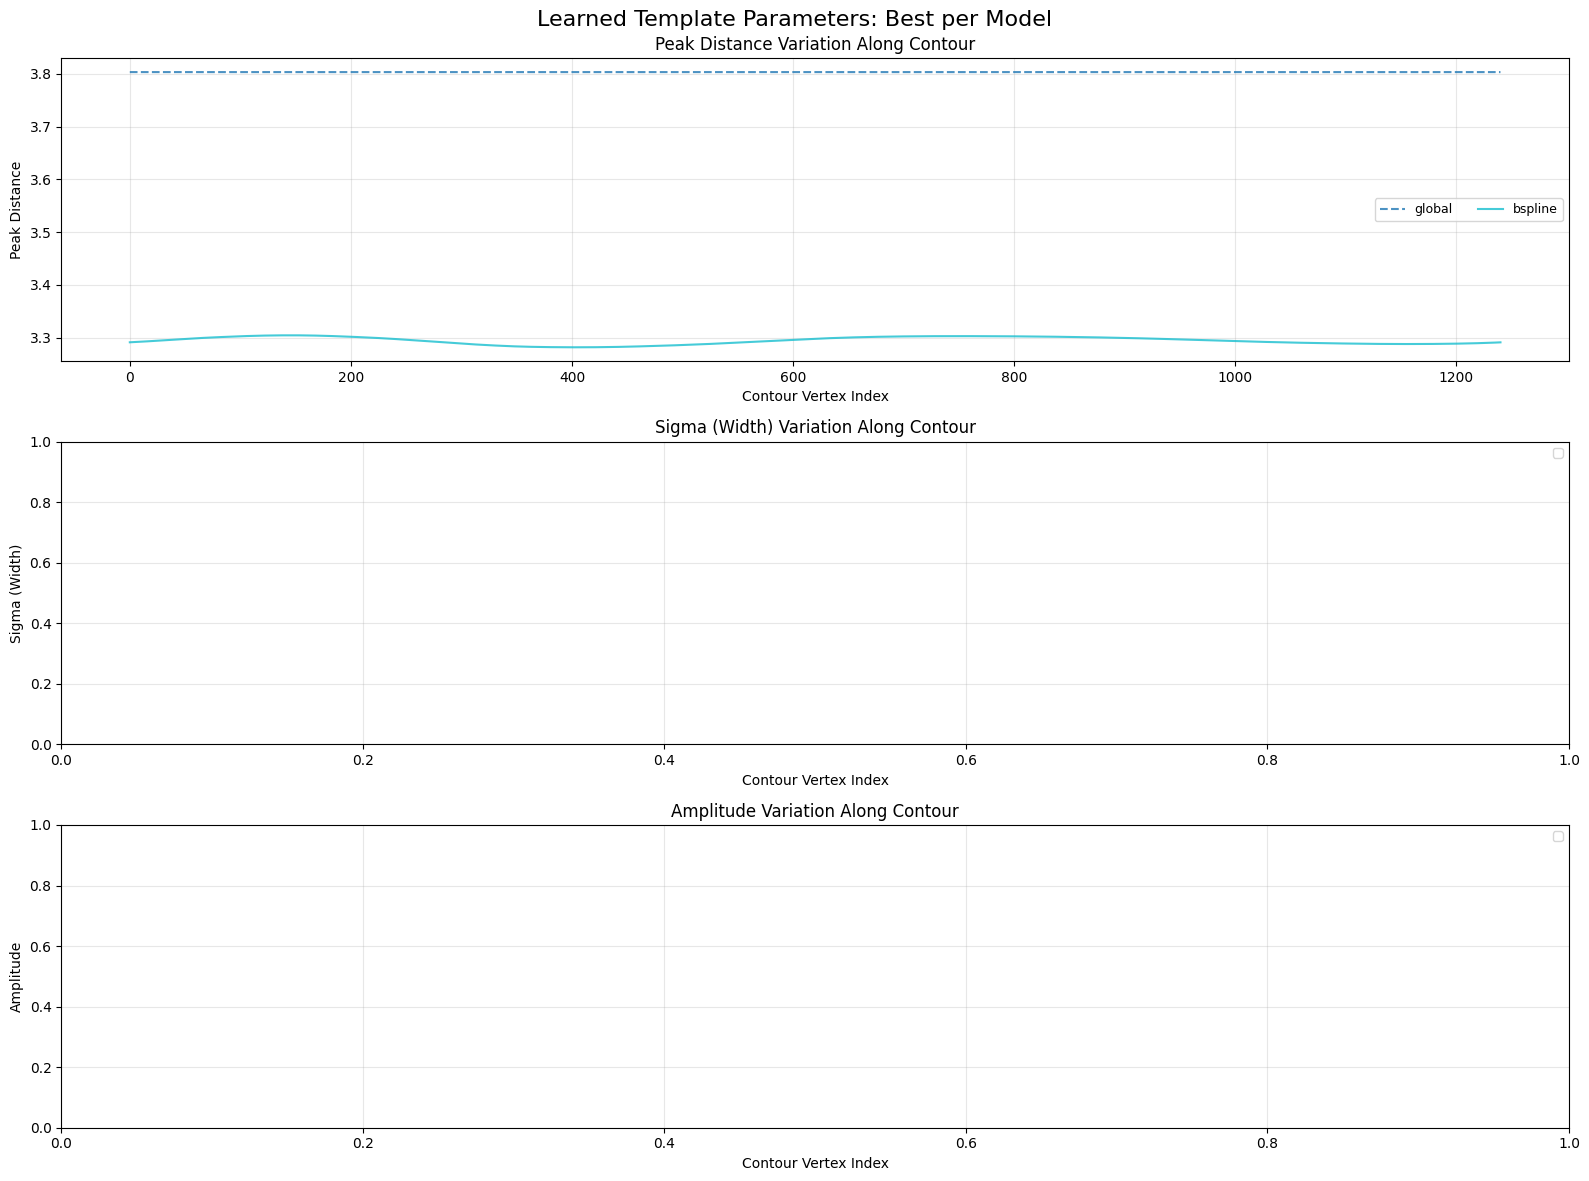


=== Parameter Statistics for Selected Cases ===


In [21]:
# 7. Learned Parameters Visualization
if results:
    print("=== Learned Template Parameters ===")

    # Select representative configurations: best accuracy per template (medium sampling)
    df_simple = pl.DataFrame(
        [
            {
                k: v
                for k, v in r.items()
                if k not in ["Contour", "Template Params", "Loss History", "RefinerObj"]
            }
            for r in results
        ]
    )

    selected_results = []
    for template in template_models:
        # Get best configuration by Final Loss
        subset = df_simple.filter(pl.col("Template") == template)
        if not subset.is_empty():
            best = subset.sort("Final Loss").head(1)
            label = best["Label"][0]
            selected_results.append([r for r in results if r["Label"] == label][0])

    print(f"\nShowing parameter variation for {len(selected_results)} template models:")
    for res in selected_results:
        print(f"  - {res['Template']} (Symmetric)")

    # Parameters to visualize
    plot_params = [
        ("peak_dist", "Peak Distance"),
        ("sigma", "Sigma (Width)"),
        ("amp", "Amplitude"),
    ]

    fig, axes = plt.subplots(len(plot_params), 1, figsize=(16, 4 * len(plot_params)))

    if len(plot_params) == 1:
        axes = [axes]

    colors = plt.cm.tab10(np.linspace(0, 1, len(selected_results)))

    for row_idx, (param_key, param_name) in enumerate(plot_params):
        ax = axes[row_idx]

        for res_idx, res in enumerate(selected_results):
            params = res["Template Params"]
            template = res["Template"]

            # Get parameter value (symmetric only)
            val = params.get(param_key)

            if val is not None:
                # Convert to array
                if np.isscalar(val) or val.ndim == 0:
                    y = np.full(len(res["Contour"]), val)
                    linestyle = "--"
                else:
                    y = val.flatten()
                    linestyle = "-"

                x = np.arange(len(y))
                label = f"{template}"

                ax.plot(
                    x,
                    y,
                    label=label,
                    linestyle=linestyle,
                    color=colors[res_idx],
                    alpha=0.8,
                    linewidth=1.5,
                )

        ax.set_ylabel(param_name)
        ax.set_xlabel("Contour Vertex Index")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9, loc="best", ncol=2)
        ax.set_title(f"{param_name} Variation Along Contour")

    plt.suptitle("Learned Template Parameters: Best per Model", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Statistics table
    print("\n=== Parameter Statistics for Selected Cases ===")
    stats_rows = []
    for res in selected_results:
        params = res["Template Params"]
        row = {"Template": res["Template"]}

        for p_key, p_name in plot_params:
            val = params.get(p_key)

            if val is not None:
                if np.isscalar(val) or val.ndim == 0:
                    row[p_name] = f"{float(val):.3f}"
                else:
                    mean_val = np.mean(val)
                    std_val = np.std(val)
                    row[p_name] = f"{mean_val:.3f} ± {std_val:.3f}"
            else:
                row[p_name] = "N/A"

        stats_rows.append(row)

    df_params = pl.DataFrame(stats_rows)

In [ ]:
# 8. Save Results for Further Analysis
output_path = Path("../output/experiments/bspline_regularization_study/results_summary.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save simplified results (without heavy objects)
save_data = {
    "results": [{k: v for k, v in r.items() 
                 if k not in ["RefinerObj"]} for r in results],
    "image": image_np,
    "initial_contour": contour_np,
    "experiment_config": {
        "templates": template_models,
        "regularization_pairs": regularization_pairs,
        "control_points": num_control_points_list,
        "focus": "regularization_effects",
        "total_experiments": len(experiments),
    }
}

joblib.dump(save_data, output_path)
print(f"Results saved to {output_path}")
print(f"Total experiments completed: {len(results)}")
print(f"\n=== Study Summary ===")
print(f"Focus: Regularization effects (applicable across templates)")
print(f"Tested: 5 regularization strategies × 2 resolutions × 2 templates")
print(f"Reduction from original full grid: 324 → {len(results)} (94% reduction)")